In [1]:
import pandas as pd  

df = pd.read_csv("cozonac_nuca.csv")

df.head()

,ID_ARTICOL,DATA,CANTITATE,VAL_IESIRE_CU_TVA,TOTAL_DISCOUNT,ADAOS
0,50647,02-JAN-23,1,15.49,0.0,14.21
1,50647,02-JAN-23,1,12.69,0.0,11.64
2,50647,02-JAN-23,1,15.49,0.0,14.21
3,50647,02-JAN-23,1,15.49,0.0,14.21
4,50647,02-JAN-23,1,15.49,0.0,14.21


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8588 entries, 0 to 8587
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_ARTICOL         8588 non-null   int64  
 1   DATA               8588 non-null   object 
 2   CANTITATE          8588 non-null   int64  
 3   VAL_IESIRE_CU_TVA  8588 non-null   float64
 4   TOTAL_DISCOUNT     8588 non-null   float64
 5   ADAOS              8588 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 402.7+ KB


In [3]:
df.describe()

,ID_ARTICOL,CANTITATE,VAL_IESIRE_CU_TVA,TOTAL_DISCOUNT,ADAOS
count,8588.0,8588.000000,8588.000000,8588.000000,8588.000000
mean,50647.0,2.008384,26.662576,2.460987,13.884739
std,0.0,3.237780,42.206995,8.599010,35.170136
min,50647.0,0.000000,0.000000,0.000000,-5.390000
25%,50647.0,1.000000,14.790000,0.000000,3.415700
50%,50647.0,1.000000,15.990000,0.000000,10.080000
75%,50647.0,2.000000,29.580000,1.300000,14.670000
max,50647.0,183.000000,2834.670000,189.000000,2600.610000


##### Focus on daily product sales 
###### As we like to predict the daily amount of product sales, 
###### we need to compute a daily aggregation of this data. For this purpose we need to extract temporal features out of the column DATA. 

In [4]:
df['DATA'] = pd.to_datetime(df['DATA'], format='%d-%b-%y', errors='coerce')

In [5]:
num_attributes_by_type = df.dtypes.value_counts()
num_attributes_by_type

float64           3
int64             2
datetime64[ns]    1
Name: count, dtype: int64

In [6]:
df.DATA

0      2023-01-02
1      2023-01-02
2      2023-01-02
3      2023-01-02
4      2023-01-02
          ...    
8583   2024-03-31
8584   2024-03-31
8585   2024-03-31
8586   2024-03-31
8587   2024-03-31
Name: DATA, Length: 8588, dtype: datetime64[ns]

### impartirea pe date

In [7]:
df["Year"] = df.DATA.dt.year
df["Quarter"] = df.DATA.dt.quarter
df["Month"] = df.DATA.dt.month
df["Weekday"] = df.DATA.dt.weekday
df["Day"] = df.DATA.dt.day
df["Dayofyear"] = df.DATA.dt.dayofyear
df["Date"] = pd.to_datetime(df[['Year', 'Month', 'Day']])

df

,ID_ARTICOL,DATA,CANTITATE,VAL_IESIRE_CU_TVA,TOTAL_DISCOUNT,ADAOS,Year,Quarter,Month,Weekday,Day,Dayofyear,Date
0,50647,2023-01-02,1,15.49,0.0,14.21,2023,1,1,0,2,2,2023-01-02
1,50647,2023-01-02,1,12.69,0.0,11.64,2023,1,1,0,2,2,2023-01-02
2,50647,2023-01-02,1,15.49,0.0,14.21,2023,1,1,0,2,2,2023-01-02
3,50647,2023-01-02,1,15.49,0.0,14.21,2023,1,1,0,2,2,2023-01-02
4,50647,2023-01-02,1,15.49,0.0,14.21,2023,1,1,0,2,2,2023-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8583,50647,2024-03-31,1,14.79,0.0,3.78,2024,1,3,6,31,91,2024-03-31
8584,50647,2024-03-31,2,29.58,0.0,7.56,2024,1,3,6,31,91,2024-03-31
8585,50647,2024-03-31,1,14.79,0.0,3.78,2024,1,3,6,31,91,2024-03-31
8586,50647,2024-03-31,1,14.79,0.0,3.78,2024,1,3,6,31,91,2024-03-31


In [8]:
# from datetime import date
# import holidays

# def is_holiday(x):
  
#   # romania_holidays = holidays.country_holidays('RO')

#   if romania_holidays.get(x):
#     return 1
#   else:
#     return 0

# df['holidays'] = df['DAT'].apply(is_holiday)
# df.head()


In [9]:
df.dtypes

ID_ARTICOL                    int64
DATA                 datetime64[ns]
CANTITATE                     int64
VAL_IESIRE_CU_TVA           float64
TOTAL_DISCOUNT              float64
ADAOS                       float64
Year                          int32
Quarter                       int32
Month                         int32
Weekday                       int32
Day                           int32
Dayofyear                     int32
Date                 datetime64[ns]
dtype: object

In [10]:
grouped_features = ["Date", "Year", "Quarter","Month", "Weekday", "Dayofyear", "Day",
                    "ID_ARTICOL"]

grouped_features2 = ["Year", "Quarter","Month", "ID_ARTICOL"]

In [28]:
daily_data = df.groupby(grouped_features2, as_index = False)[["CANTITATE", "ADAOS"]].sum()
# daily_data["ADAOS"] = df.groupby(grouped_features).ADAOS.sum()
# daily_data = daily_data.reset_index()
daily_data

,Year,Quarter,Month,ID_ARTICOL,CANTITATE,ADAOS
0,2023,1,1,50647,501,6923.05000
1,2023,1,2,50647,495,6843.74000
2,2023,1,3,50647,335,4656.48000
3,2023,2,4,50647,3729,37599.92000
4,2023,2,5,50647,866,12014.66000
5,2023,2,6,50647,696,9760.39000
6,2023,3,7,50647,646,9156.67000
7,2023,3,8,50647,794,11423.73000
8,2023,3,9,50647,613,4234.65300
9,2023,4,10,50647,691,3859.89610


In [12]:
daily_data.loc[:, ["CANTITATE", "ADAOS"]].describe()

,CANTITATE,ADAOS
count,15.000000,15.000000
mean,1149.866667,7949.475935
std,1260.838376,8886.484592
min,335.000000,1570.134600
25%,629.500000,3279.947625
50%,696.000000,4656.480000
75%,836.000000,9458.530000
max,4668.000000,37599.920000


In [31]:
df = df.sort_values('Date')


### Gruparea datelor + index 

In [30]:
# creez artificial o coloana cu an luna si 01 , group by cantitate si sum
# pun idexul pe date 

df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

daily_data2 = df.groupby('date')[['CANTITATE', 'ADAOS']].sum().reset_index()

daily_data2.set_index('date', inplace=True)

print(daily_data2)

            CANTITATE        ADAOS
date                              
2023-01-01        501   6923.05000
2023-02-01        495   6843.74000
2023-03-01        335   4656.48000
2023-04-01       3729  37599.92000
2023-05-01        866  12014.66000
2023-06-01        696   9760.39000
2023-07-01        646   9156.67000
2023-08-01        794  11423.73000
2023-09-01        613   4234.65300
2023-10-01        691   3859.89610
2023-11-01        806   1570.13460
2023-12-01       4668   4148.12657
2024-01-01       1007   1996.79918
2024-02-01        653   2353.89042
2024-03-01        748   2699.99915


#### Matplotlib

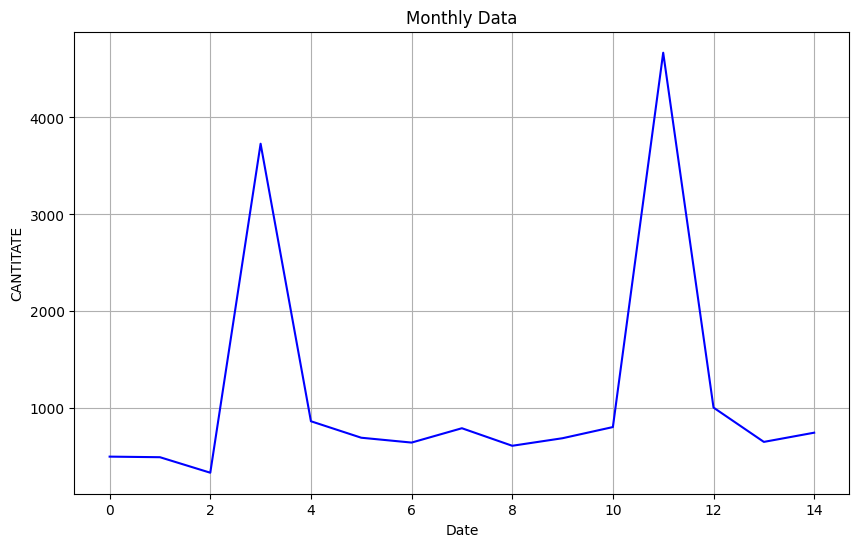

In [33]:
import numpy as np  # libraria pentru functii matematice
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,mean_absolute_percentage_error

import seaborn as sns # pt grafice statistice
import matplotlib.pyplot as plt

# df_toplot = daily_data.set_index('Date').asfreq('ME')

df_toplot = daily_data

plt.figure(figsize=(10, 6))  
plt.plot(df_toplot.index, df_toplot['CANTITATE'], linestyle='-', color='b')  
plt.xlabel('Date')
plt.ylabel('CANTITATE')
plt.title('Monthly Data')
plt.grid(True)
plt.show()

#### Plotly

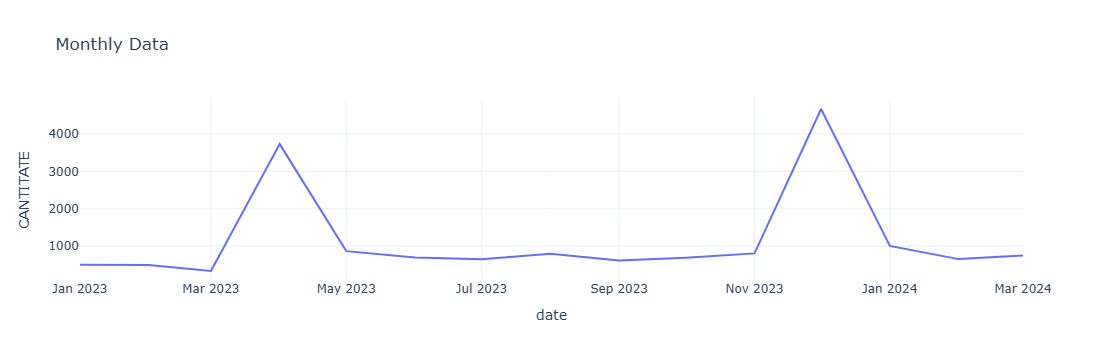

In [34]:
import plotly.express as px

df_toplot = daily_data2

fig = px.line(df_toplot, x=df_toplot.index, y='CANTITATE', title='Monthly Data',
              labels={'x': 'Date', 'CANTITATE': 'CANTITATE'})
fig.update_layout(template='plotly_white')
fig.show()

#### Seasonal-Trend decomposition using LOESS (STL)

Formula de bază a descompunerii STL este:

  y(t) = Trend(t) + Sezonalitate(t) + Rezidu (t)

*Trendul* – reflectă evoluția pe termen lung a seriei (creșteri sau descreșteri constante).  
*Sezonalitatea* – evidențiază modelele periodice, adică variațiile care se repetă la intervale regulate (zilnic, lunar, anual etc.).  
*Reziduul* – reprezintă fluctuațiile rămase după ce se scad trendul și sezonalitatea, adică zgomotul sau variațiile care nu pot fi explicate de primele două componente.


DatetimeIndex(['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01'],
              dtype='datetime64[ns]', name='date', freq=None)


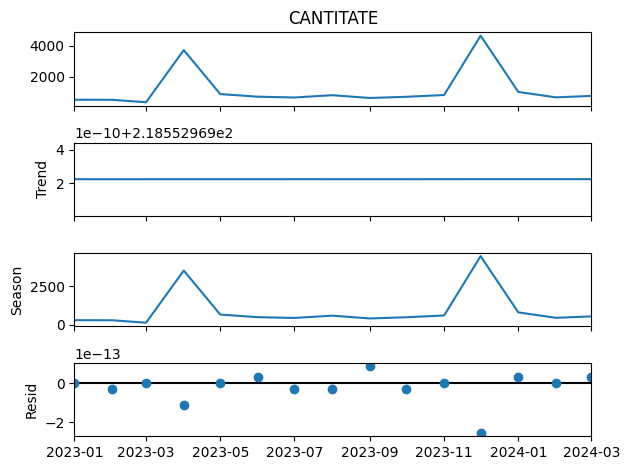

In [37]:
from statsmodels.tsa.seasonal import STL

print(daily_data2.index)

daily_data = daily_data2.sort_index()

# STL decomposition 
stl = STL(daily_data2['CANTITATE'], period=365)  # Yearly seasonality
result = stl.fit()

result.plot()
plt.show()

## ARIMA model
#### - prognozarea unei serii de timp folosind valorile anterioare ale seriei

 Dacă sunt utilizate numai valorile anterioare ale seriei de timp pentru a prezice valorile viitoare ale acesteia, aceasta se numește <b>Univariate Time Series Forecasting</b>.

Dacă sunt utilizați alți predictori decât serii (a.k.a variabile exogene) pentru a prognoza, este vorba de <b>Multi Variate Time Series Forecasting</b>.

##### ARIMA, prescurtare de la „AutoRegressive Integrated Moving Average”, este un algoritm de prognoză bazat pe ideea că informațiile din valorile trecute ale seriei de timp pot fi folosite singure pentru a prezice valorile viitoare ( adică propriile întârzieri și erorile de prognoză întârziate, astfel încât ecuația să poată fi utilizată ) .

„Autoregresiv” în ARIMA înseamnă că este un model de regresie liniară care își folosește propriile întârzieri ca predictori. După cum știți, modelele de regresie liniară funcționează cel mai bine atunci când predictorii nu sunt corelați și sunt independenți unul de celălalt.  


Modelul ARIMA(1, 1, 1):  
AR(1) - componenta autoregresivă : Modelul folosește valoarea imediat anterioară ca predicator.  
I(1): Se diferențiază o dată seria pentru a elimina trendul și a face seria staționară.  
MA(1) - componenta medie mobilă: Eroarea din perioada precedentă este inclusă în model.


                               SARIMAX Results                                
Dep. Variable:              CANTITATE   No. Observations:                   15
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -121.158
Date:                Fri, 14 Mar 2025   AIC                            248.315
Time:                        11:22:48   BIC                            250.232
Sample:                    01-01-2023   HQIC                           248.138
                         - 03-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0354      2.636     -0.013      0.989      -5.202       5.131
ma.L1         -0.9991      0.394     -2.536      0.011      -1.771      -0.227
sigma2       1.63e+06   2.51e-07   6.48e+12      0.0

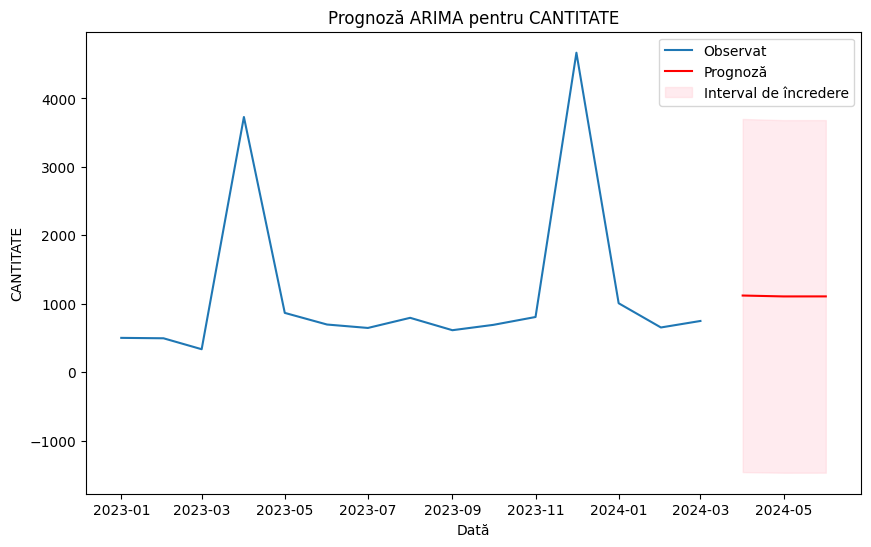

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(daily_data2['CANTITATE'], order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

# prognoze pentru următoarele 3 perioade
forecast = model_fit.get_forecast(steps=3)
forecast_df = forecast.summary_frame()

plt.figure(figsize=(10, 6))
plt.plot(daily_data.index, daily_data2['CANTITATE'], label='Observat')
plt.plot(forecast_df.index, forecast_df['mean'], label='Prognoză', color='red')
plt.fill_between(forecast_df.index,
                 forecast_df['mean_ci_lower'],
                 forecast_df['mean_ci_upper'], 
                 color='pink', alpha=0.3, label='Interval de încredere')
plt.title("Prognoză ARIMA pentru CANTITATE")
plt.xlabel("Dată")
plt.ylabel("CANTITATE")
plt.legend()
plt.show()

#  articole cu date mai vaste - sa fie impartite datele in test si antrenament 

#  Exponential smoothing 
#  SARIMA , SARIMAX

#  Forecast cu STL


### Long - Short Term Memory 
- uses two different paths for predictions: long term memory and short term memory\
Math:
- uses Sigmoid activation function( turns any x_axis coordinate and turns it into a y-axis coordinate between 0 - 1)
- and Tanh activation function (turns any x_axis coordinate and turns it into a y-axis coordinate between -1 <-> 1 )